In [1]:
# EDA and Preprocessing for HDB Resale Price Prediction
# Based on dataset from Jan 2017 onwards
# ============================================================
# UPDATED EDA & RIDGE REGRESSION FOR HDB PRICE PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — Ridge regression predictor ready")

✅ Libraries loaded — Ridge regression predictor ready


In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================
#url = "https://raw.githubusercontent.com/kohjiaxuan/Predicting-HDB-Price-with-Machine-Learning/master/resale-flat-prices-based-on-registration-date-from-jan-2017-onwards.csv"
url = "https://media.githubusercontent.com/media/SzeMainWONG/datasets/main/dataset/hdb_resale_prices.csv"
df = pd.read_csv(url)
print("Initial dataset shape:", df.shape)

print(f"📥 Loaded {len(df):,} records")
print(f"📅 Date range: {df['month'].min()} to {df['month'].max()}")

Initial dataset shape: (50432, 11)
📥 Loaded 50,432 records
📅 Date range: 2017-01 to 2019-05


In [3]:
# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

# 2.1 Parse remaining lease
def parse_lease(lease_str):
    if pd.isna(lease_str):
        return np.nan
    parts = lease_str.split()
    years = 0
    months = 0
    for i, part in enumerate(parts):
        if part in ['years', 'year']:
            years = int(parts[i-1])
        elif part in ['months', 'month']:
            months = int(parts[i-1])
    return years + months/12.0

df['remaining_lease_years'] = df['remaining_lease'].apply(parse_lease)

# 2.2 Extract storey midpoint
def extract_storey_mid(storey_str):
    if pd.isna(storey_str):
        return np.nan
    parts = storey_str.split(' TO ')
    if len(parts) == 2:
        return (int(parts[0]) + int(parts[1])) / 2.0
    return np.nan

df['storey_mid'] = df['storey_range'].apply(extract_storey_mid)

# 2.3 Convert month to datetime
df['month'] = pd.to_datetime(df['month'])
df['year'] = df['month'].dt.year
df['month_num'] = df['month'].dt.month

# 2.4 Calculate flat age
df['flat_age'] = df['year'] - df['lease_commence_date']

print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE")
print("="*80)
print(f"New features created: remaining_lease_years, storey_mid, year, month_num, flat_age")


FEATURE ENGINEERING COMPLETE
New features created: remaining_lease_years, storey_mid, year, month_num, flat_age


### Drop features, refer to correlation and multicollinearity analysis on ipynb: "feature engineering"

In [5]:
# ============================================================
# 3. DROP PROBLEMATIC FEATURES (MULTICOLLINEARITY)
# ============================================================

# Features to drop due to mathematical relationships or multicollinearity
features_to_drop = [
    'lease_commence_date',    # Highly correlated with flat_age (r ≈ -0.99)
    'remaining_lease_years',  # Mathematical function of flat_age
    'month',                  # Redundant with year and month_num
    'remaining_lease',        # Original string version
    'storey_range',           # Redundant with storey_mid
    'block',                  # Too granular, not predictive
    'street_name',            # Too granular, not predictive
    'year',
    'month_num'
]

df_clean = df.drop(columns=features_to_drop, errors='ignore')

print("\n" + "="*80)
print("REMOVED PROBLEMATIC FEATURES")
print("="*80)
print(f"Removed: {features_to_drop}")
print(f"Remaining numerical features: {df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()}")



REMOVED PROBLEMATIC FEATURES
Removed: ['lease_commence_date', 'remaining_lease_years', 'month', 'remaining_lease', 'storey_range', 'block', 'street_name', 'year', 'month_num']
Remaining numerical features: ['floor_area_sqm', 'resale_price', 'storey_mid', 'flat_age']


In [6]:
# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================
print("\n" + "="*80)
print("MISSING VALUE HANDLING")
print("="*80)
print(f"Missing values before: {df_clean.isnull().sum().sum()}")

# Drop rows with missing target or critical features
df_clean = df_clean.dropna(subset=['resale_price', 'floor_area_sqm', 'storey_mid'])

# Fill remaining numerical NAs with median
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical NAs with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Missing values after: {df_clean.isnull().sum().sum()}")

df_clean.head()


MISSING VALUE HANDLING
Missing values before: 0
Missing values after: 0


,town,flat_type,floor_area_sqm,flat_model,resale_price,storey_mid,flat_age
0,ANG MO KIO,2 ROOM,44.0,Improved,232000.0,11.0,38
1,ANG MO KIO,3 ROOM,67.0,New Generation,250000.0,2.0,39
2,ANG MO KIO,3 ROOM,67.0,New Generation,262000.0,2.0,37
3,ANG MO KIO,3 ROOM,68.0,New Generation,265000.0,5.0,37
4,ANG MO KIO,3 ROOM,67.0,New Generation,265000.0,2.0,37



UPDATED CORRELATION ANALYSIS (Problematic Features Removed)

Feature Correlation with Resale Price:
       feature  correlation_with_price
floor_area_sqm                0.631891
    storey_mid                0.379446
      flat_age               -0.332759

Feature-Feature Correlation Matrix:
                floor_area_sqm  storey_mid  flat_age
floor_area_sqm           1.000       0.026    -0.244
storey_mid               0.026       1.000    -0.288
flat_age                -0.244      -0.288     1.000


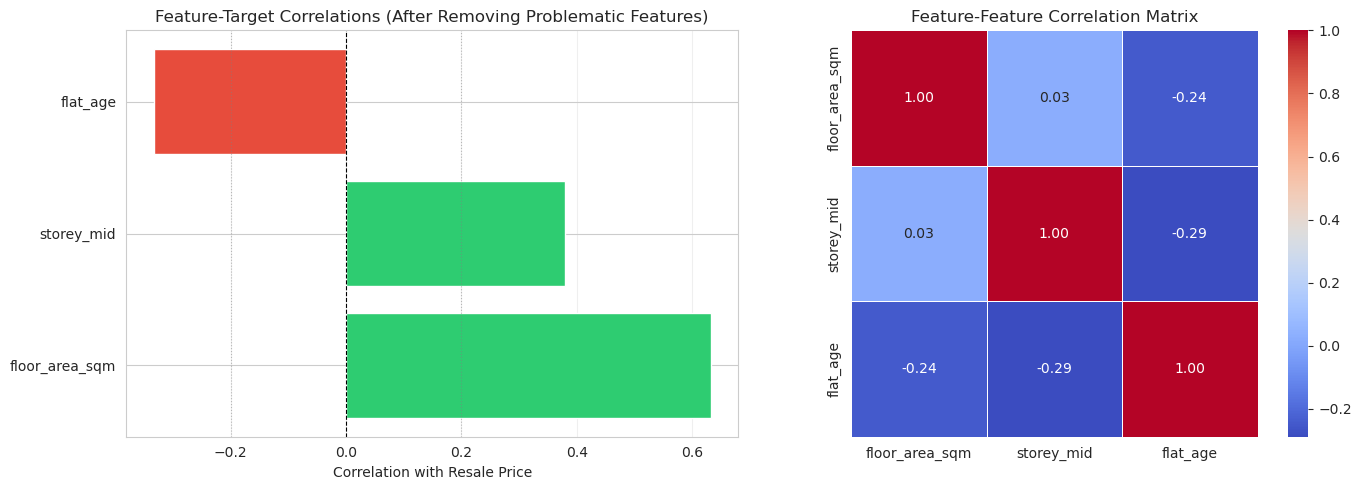

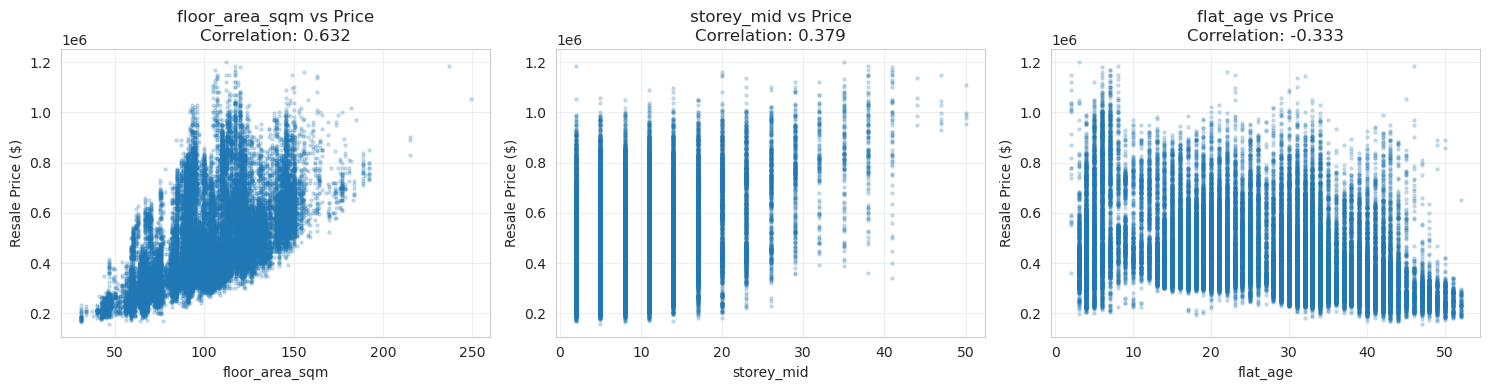

In [7]:
# ============================================================
# 5. UPDATED EDA - CORRELATION ANALYSIS (WITHOUT PROBLEMATIC FEATURES)
# ============================================================

print("\n" + "="*80)
print("UPDATED CORRELATION ANALYSIS (Problematic Features Removed)")
print("="*80)

# 5.1 Correlation with target
numerical_features = ['floor_area_sqm', 'storey_mid', 'flat_age']   #, 'year', 'month_num']
target_corr = pd.DataFrame({
    'feature': numerical_features,
    'correlation_with_price': [df_clean[col].corr(df_clean['resale_price']) for col in numerical_features]
}).sort_values('correlation_with_price', key=abs, ascending=False)

print("\nFeature Correlation with Resale Price:")
print(target_corr.to_string(index=False))

# 5.2 Feature-feature correlation (multicollinearity check)
print("\nFeature-Feature Correlation Matrix:")
corr_matrix = df_clean[numerical_features].corr()
print(corr_matrix.round(3))

# 5.3 Visualize correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation with target
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr['correlation_with_price']]
axes[0].barh(target_corr['feature'], target_corr['correlation_with_price'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(x=0.2, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].axvline(x=-0.2, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel('Correlation with Resale Price')
axes[0].set_title('Feature-Target Correlations (After Removing Problematic Features)')
axes[0].grid(axis='x', alpha=0.3)

# Heatmap of feature-feature correlations
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True, ax=axes[1])
axes[1].set_title('Feature-Feature Correlation Matrix')

plt.tight_layout()
plt.show()

# 5.4 Scatter plots for top features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
top_features = target_corr.head(3)['feature'].tolist()

for i, feature in enumerate(top_features):
    axes[i].scatter(df_clean[feature], df_clean['resale_price'], alpha=0.2, s=5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Resale Price ($)')
    axes[i].set_title(f'{feature} vs Price\nCorrelation: {target_corr[target_corr["feature"]==feature]["correlation_with_price"].values[0]:.3f}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


COMPLETE MULTICOLLINEARITY CHECK

--------------------------------------------------------------------------------
NUMERICAL FEATURES MULTICOLLINEARITY CHECK
--------------------------------------------------------------------------------
Numerical features being checked: ['floor_area_sqm', 'storey_mid', 'flat_age']

Numerical Feature Correlation Matrix:
                floor_area_sqm  storey_mid  flat_age
floor_area_sqm           1.000       0.026    -0.244
storey_mid               0.026       1.000    -0.288
flat_age                -0.244      -0.288     1.000

✅ No high correlation pairs found (|corr| ≤ 0.7)


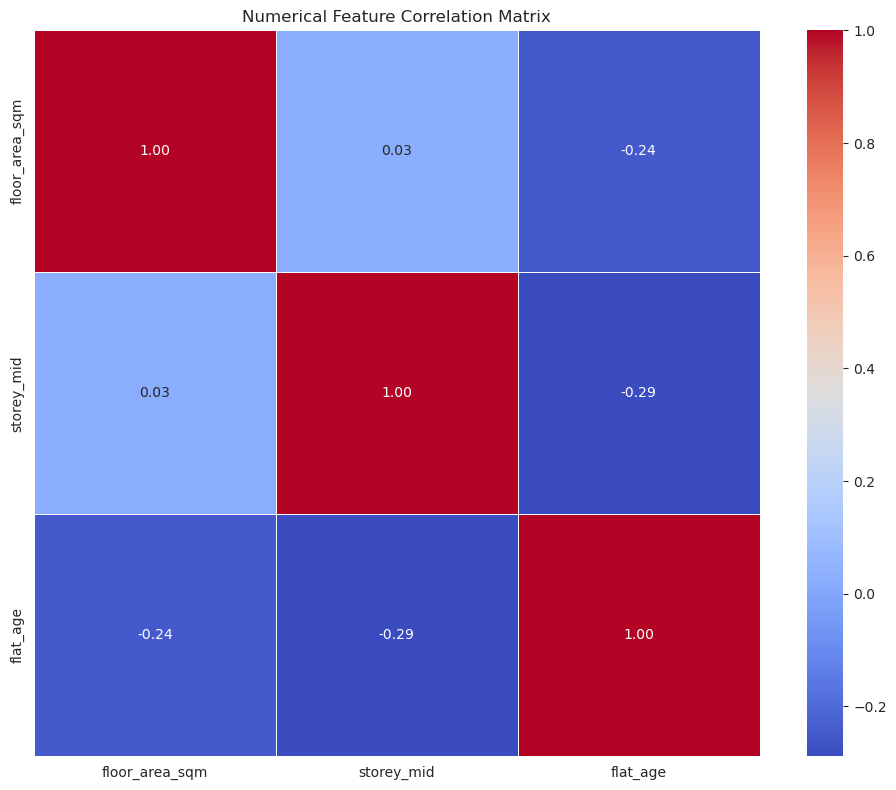


--------------------------------------------------------------------------------
VIF (VARIANCE INFLATION FACTOR) - NUMERICAL FEATURES
--------------------------------------------------------------------------------
       feature      VIF
      flat_age 1.161174
    storey_mid 1.093052
floor_area_sqm 1.065461

VIF Interpretation:
  VIF > 10:  ❌ High multicollinearity - consider removing feature
  VIF > 5:   ⚠️  Moderate multicollinearity - consider combining features
  VIF < 5:   ✅ Acceptable multicollinearity

✅ All numerical features have VIF ≤ 10 (acceptable)

--------------------------------------------------------------------------------
CATEGORICAL FEATURES - ASSOCIATION MEASURES
--------------------------------------------------------------------------------
Categorical features being checked: ['town', 'flat_type', 'flat_model']

TOWN - Unique values: 26
Top 5 categories:
town
WOODLANDS      3910
JURONG WEST    3864
SENGKANG       3777
PUNGGOL        3310
YISHUN         3145

F

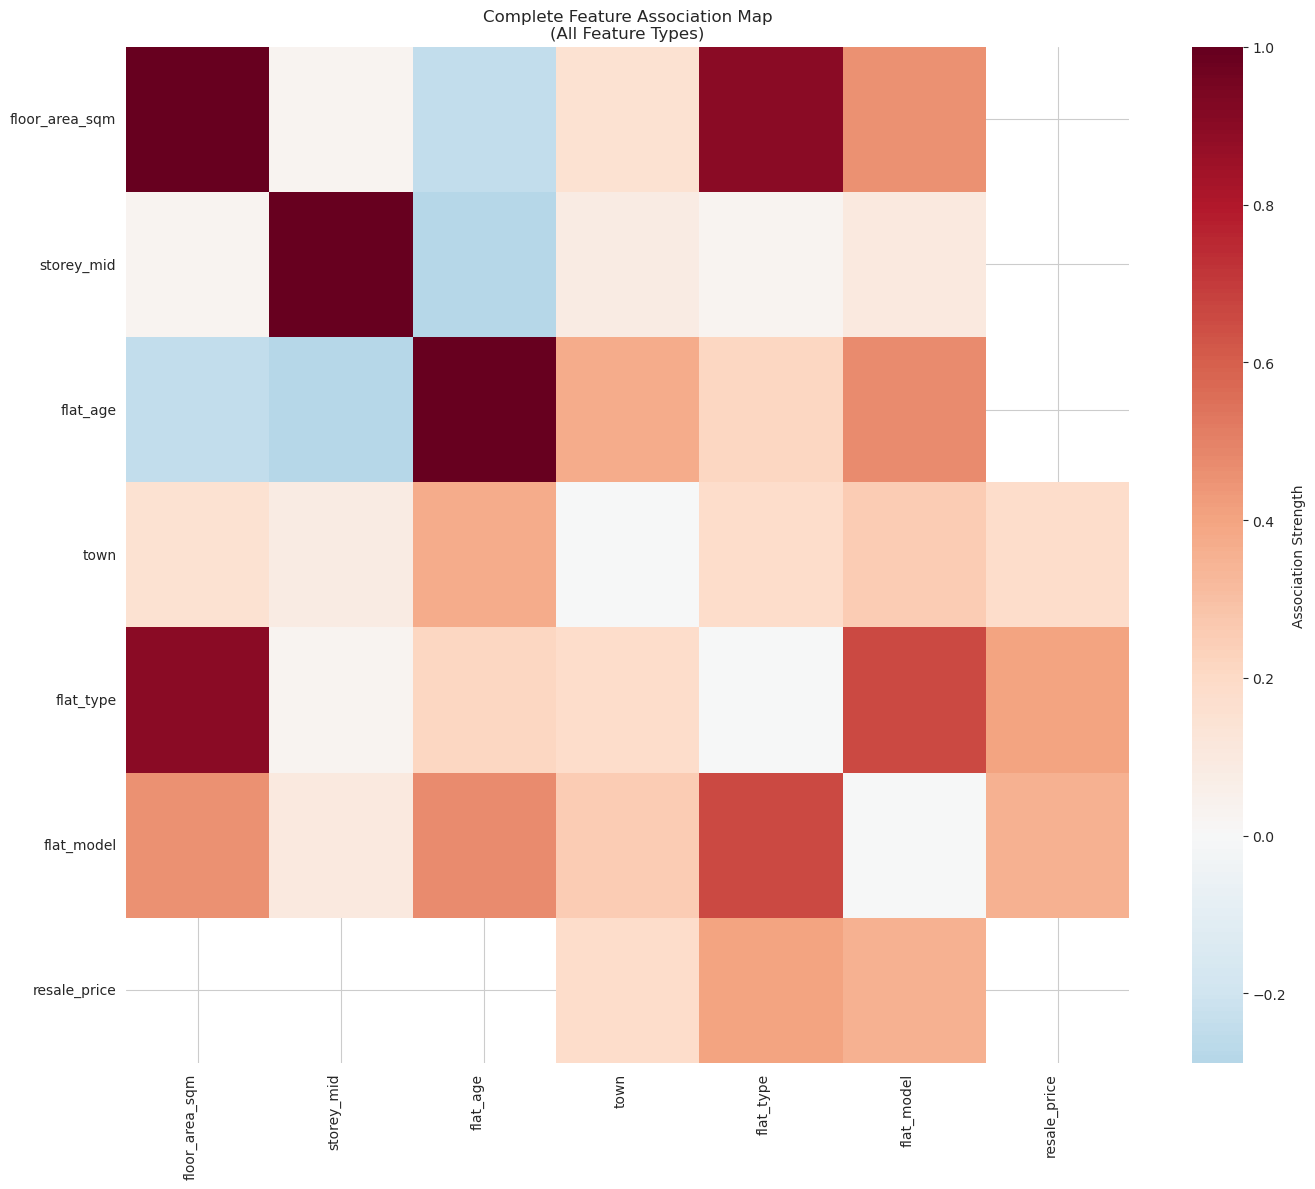


✅ Complete multicollinearity check finished!


In [8]:
# ============================================================
# 5.5 COMPLETE MULTICOLLINEARITY CHECK (Numerical + Categorical)
# ============================================================

print("\n" + "="*80)
print("COMPLETE MULTICOLLINEARITY CHECK")
print("="*80)

# ============================================================
# 5.5.1 NUMERICAL FEATURES - Correlation Matrix & VIF
# ============================================================

print("\n" + "-"*80)
print("NUMERICAL FEATURES MULTICOLLINEARITY CHECK")
print("-"*80)

# Get numerical features (excluding target)
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('resale_price')  # Remove target

print(f"Numerical features being checked: {numerical_cols}")

# Correlation matrix
num_corr_matrix = df_clean[numerical_cols].corr()
print("\nNumerical Feature Correlation Matrix:")
print(num_corr_matrix.round(3))

# Identify highly correlated pairs
high_corr_pairs = []
threshold = 0.7
for i in range(len(num_corr_matrix.columns)):
    for j in range(i+1, len(num_corr_matrix.columns)):
        if abs(num_corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'feature1': num_corr_matrix.columns[i],
                'feature2': num_corr_matrix.columns[j],
                'correlation': num_corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\n⚠️ HIGH CORRELATION PAIRS (|corr| > {threshold}):")
    for pair in high_corr_pairs:
        print(f"  {pair['feature1']} ↔ {pair['feature2']}: {pair['correlation']:.3f}")
else:
    print(f"\n✅ No high correlation pairs found (|corr| ≤ {threshold})")

# Visualize numerical correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(num_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True)
plt.title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# ============================================================
# 5.5.2 VIF (Variance Inflation Factor) for Numerical Features
# ============================================================

print("\n" + "-"*80)
print("VIF (VARIANCE INFLATION FACTOR) - NUMERICAL FEATURES")
print("-"*80)

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    # Handle any remaining missing values
    df_vif = df_clean[numerical_cols].copy()
    
    # Standardize numerical features for VIF
    from sklearn.preprocessing import StandardScaler
    scaler_vif = StandardScaler()
    df_vif_scaled = pd.DataFrame(
        scaler_vif.fit_transform(df_vif),
        columns=df_vif.columns
    )
    
    # Calculate VIF
    vif_data = pd.DataFrame()
    vif_data['feature'] = numerical_cols
    vif_data['VIF'] = [variance_inflation_factor(df_vif_scaled.values, i) 
                       for i in range(len(numerical_cols))]
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print(vif_data.to_string(index=False))
    
    # VIF Interpretation
    print("\nVIF Interpretation:")
    print("  VIF > 10:  ❌ High multicollinearity - consider removing feature")
    print("  VIF > 5:   ⚠️  Moderate multicollinearity - consider combining features")
    print("  VIF < 5:   ✅ Acceptable multicollinearity")
    
    # Highlight problematic features
    high_vif = vif_data[vif_data['VIF'] > 10]
    if not high_vif.empty:
        print(f"\n⚠️ Features with VIF > 10 (remove or combine):")
        print(high_vif.to_string(index=False))
        
        # Recommendation for removal
        high_vif_features = high_vif['feature'].tolist()
        print(f"\n🔧 Recommendation: Consider removing or combining: {high_vif_features}")
    else:
        print("\n✅ All numerical features have VIF ≤ 10 (acceptable)")
        
    moderate_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]
    if not moderate_vif.empty:
        print(f"\n⚠️ Features with 5 < VIF ≤ 10 (consider monitoring):")
        print(moderate_vif.to_string(index=False))
        
except ImportError:
    print("⚠️ statsmodels not installed. Install with: pip install statsmodels")
    print("Skipping VIF calculation...")
    print("Alternative: Use correlation matrix above for multicollinearity detection")
    vif_data = None

# ============================================================
# 5.5.3 CATEGORICAL FEATURES - Cramér's V & Association
# ============================================================

print("\n" + "-"*80)
print("CATEGORICAL FEATURES - ASSOCIATION MEASURES")
print("-"*80)

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features being checked: {categorical_cols}")

# Frequency distribution for categorical features
for col in categorical_cols:
    print(f"\n{col.upper()} - Unique values: {df_clean[col].nunique()}")
    print(f"Top 5 categories:")
    print(df_clean[col].value_counts().head(5).to_string())
    
    # Check if any category has very few samples (< 5)
    small_categories = df_clean[col].value_counts()[df_clean[col].value_counts() < 5]
    if not small_categories.empty:
        print(f"⚠️ Small categories (n < 5): {len(small_categories)} categories")
        print(f"   Examples: {small_categories.head(5).index.tolist()}")

# ============================================================
# 5.5.4 Cramér's V for Categorical-Categorical Association
# ============================================================

try:
    from scipy.stats import chi2_contingency
    
    def cramers_v(x, y):
        """Calculate Cramér's V statistic for association between two categorical variables"""
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    
    print("\nCategorical-Categorical Association (Cramér's V):")
    print("-" * 50)
    
    # Calculate Cramér's V for all pairs of categorical features
    cat_pairs = []
    for i in range(len(categorical_cols)):
        for j in range(i+1, len(categorical_cols)):
            try:
                cramers = cramers_v(df_clean[categorical_cols[i]], df_clean[categorical_cols[j]])
                cat_pairs.append({
                    'feature1': categorical_cols[i],
                    'feature2': categorical_cols[j],
                    'cramers_v': cramers
                })
            except:
                pass  # Skip if calculation fails
    
    if cat_pairs:
        # Sort by Cramér's V
        cat_pairs_df = pd.DataFrame(cat_pairs).sort_values('cramers_v', ascending=False)
        
        print("\nTop 10 Most Associated Categorical Pairs:")
        print(cat_pairs_df.head(10).to_string(index=False))
        
        # Identify high association (Cramér's V > 0.5)
        high_assoc = cat_pairs_df[cat_pairs_df['cramers_v'] > 0.5]
        if not high_assoc.empty:
            print(f"\n⚠️ HIGH ASSOCIATION PAIRS (Cramér's V > 0.5):")
            print(high_assoc.to_string(index=False))
            print("\n🔧 Recommendation: Consider combining or removing one from each pair")
        else:
            print("\n✅ No high association pairs found (Cramér's V ≤ 0.5)")
    else:
        print("⚠️ Cannot calculate Cramér's V - check if categorical features exist")

except ImportError:
    print("⚠️ scipy not fully installed. Skipping Cramér's V calculation...")
    print("Alternative: Check category overlap manually")
    cat_pairs_df = None

# ============================================================
# 5.5.5 NUMERICAL-CATEGORICAL ASSOCIATION - ANOVA/Correlation Ratio
# ============================================================

print("\n" + "-"*80)
print("NUMERICAL-CATEGORICAL ASSOCIATION (Correlation Ratio/ANOVA)")
print("-"*80)

def correlation_ratio(categorical, numerical):
    """Calculate correlation ratio (eta-squared) for categorical-numerical relationship"""
    categories = categorical.unique()
    group_means = [numerical[categorical == cat].mean() for cat in categories]
    overall_mean = numerical.mean()
    
    # Between-group variance
    between_var = sum([len(numerical[categorical == cat]) * (mean - overall_mean)**2 
                      for cat, mean in zip(categories, group_means)])
    
    # Total variance
    total_var = sum((numerical - overall_mean)**2)
    
    return between_var / total_var if total_var != 0 else 0

if len(categorical_cols) > 0 and len(numerical_cols) > 0:
    num_cat_assoc = []
    
    # Check association with target (resale_price) first
    for cat_col in categorical_cols:
        try:
            eta = correlation_ratio(df_clean[cat_col], df_clean['resale_price'])
            num_cat_assoc.append({
                'categorical': cat_col,
                'numerical': 'resale_price',
                'correlation_ratio': eta
            })
        except:
            pass
    
    # Check all numerical-categorical pairs (sample - only with key numerical features)
    key_num_cols = ['floor_area_sqm', 'storey_mid', 'flat_age']
    for num_col in key_num_cols:
        for cat_col in categorical_cols:
            try:
                eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
                num_cat_assoc.append({
                    'categorical': cat_col,
                    'numerical': num_col,
                    'correlation_ratio': eta
                })
            except:
                pass
    
    if num_cat_assoc:
        num_cat_df = pd.DataFrame(num_cat_assoc).sort_values('correlation_ratio', ascending=False)
        print("\nTop Associations (Categorical → Numerical):")
        print(num_cat_df.head(15).to_string(index=False))
        
        print("\nInterpretation of Correlation Ratio (η²):")
        print("  η² > 0.3:  Strong association (categorical explains >30% of numerical variance)")
        print("  0.1 < η² ≤ 0.3: Moderate association")
        print("  η² ≤ 0.1:  Weak association")
    else:
        print("⚠️ Cannot calculate correlation ratios - check data")
else:
    print("⚠️ Need both categorical and numerical features for this check")

# ============================================================
# 5.5.6 SUMMARY & RECOMMENDATIONS
# ============================================================

print("\n" + "="*80)
print("MULTICOLLINEARITY CHECK - SUMMARY & RECOMMENDATIONS")
print("="*80)

# Compile all findings
recommendations = []

# Numerical recommendations
if 'high_vif_features' in locals() and high_vif_features:
    recommendations.append(f"⚠️ Remove or combine numerical features with VIF > 10: {high_vif_features}")

if 'high_corr_pairs' in locals() and high_corr_pairs:
    for pair in high_corr_pairs:
        recommendations.append(f"⚠️ Consider removing one from numerical pair: {pair['feature1']} ↔ {pair['feature2']} (corr: {pair['correlation']:.3f})")

# Categorical recommendations
if 'cat_pairs_df' in locals() and cat_pairs_df is not None:
    high_cat_assoc = cat_pairs_df[cat_pairs_df['cramers_v'] > 0.5]
    if not high_cat_assoc.empty:
        for _, row in high_cat_assoc.head(5).iterrows():
            recommendations.append(f"⚠️ Consider combining categories: {row['feature1']} ↔ {row['feature2']} (Cramér's V: {row['cramers_v']:.3f})")

# Print recommendations
if recommendations:
    print("\n🔧 ACTION ITEMS:")
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")
else:
    print("\n✅ No multicollinearity issues detected! Dataset is clean for modeling.")

# ============================================================
# 5.5.7 VISUALIZATION: Complete Feature Association Map
# ============================================================

print("\n" + "-"*80)
print("VISUALIZING COMPLETE FEATURE ASSOCIATIONS")
print("-"*80)

# Create a combined association matrix for all features
all_features = numerical_cols + categorical_cols
n_features = len(all_features)

# Initialize association matrix
assoc_matrix = pd.DataFrame(np.zeros((n_features, n_features)), 
                            index=all_features, columns=all_features)

# Fill numerical-numerical with Pearson correlation
for i, f1 in enumerate(numerical_cols):
    for j, f2 in enumerate(numerical_cols):
        assoc_matrix.loc[f1, f2] = df_clean[f1].corr(df_clean[f2])

# Fill categorical-categorical with Cramér's V
if 'cat_pairs_df' in locals() and cat_pairs_df is not None and not cat_pairs_df.empty:
    for _, row in cat_pairs_df.iterrows():
        assoc_matrix.loc[row['feature1'], row['feature2']] = row['cramers_v']
        assoc_matrix.loc[row['feature2'], row['feature1']] = row['cramers_v']

# Fill numerical-categorical with correlation ratio
if 'num_cat_df' in locals() and num_cat_df is not None and not num_cat_df.empty:
    for _, row in num_cat_df.iterrows():
        assoc_matrix.loc[row['categorical'], row['numerical']] = row['correlation_ratio']
        assoc_matrix.loc[row['numerical'], row['categorical']] = row['correlation_ratio']

# Visualize
plt.figure(figsize=(14, 12))
sns.heatmap(assoc_matrix, annot=False, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Association Strength'})
plt.title('Complete Feature Association Map\n(All Feature Types)')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✅ Complete multicollinearity check finished!")
print("="*80)


FEATURE ENGINEERING - COMBINING CATEGORICAL FEATURES
Original flat_type unique values: 7
Original flat_model unique values: 20
Combined flat_category unique values: 44

Top 10 Combined Categories:
flat_category
4 ROOM - Model A              12125
5 ROOM - Improved              8595
3 ROOM - New Generation        4652
3 ROOM - Improved              3233
3 ROOM - Model A               2864
4 ROOM - Premium Apartment     2830
4 ROOM - New Generation        2540
EXECUTIVE - Apartment          2114
5 ROOM - Premium Apartment     2009
4 ROOM - Simplified            1607


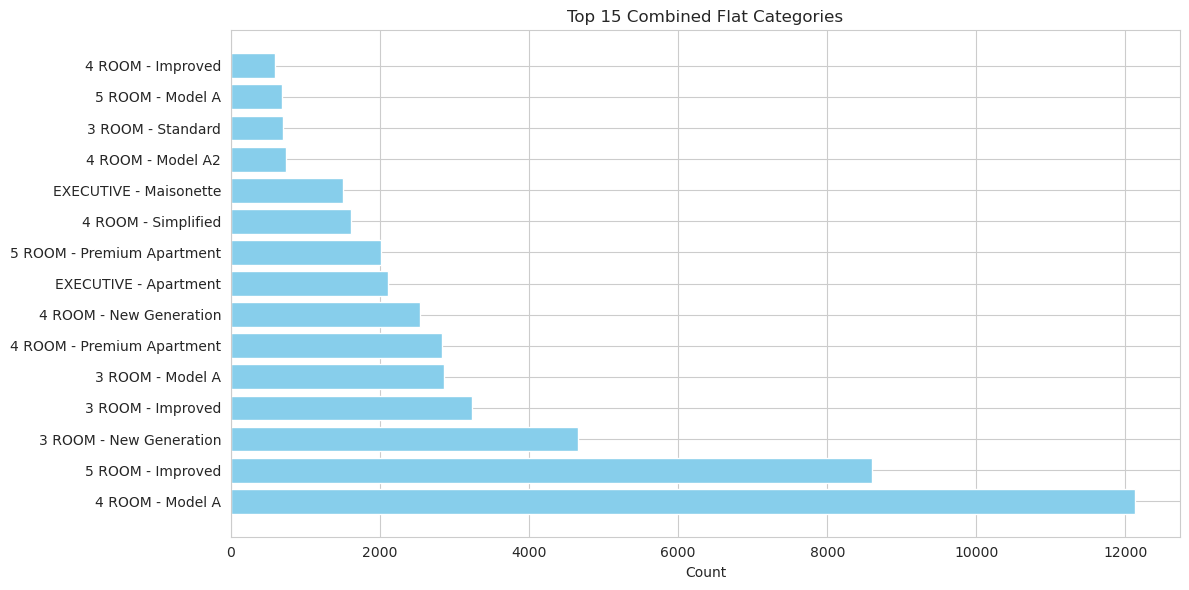

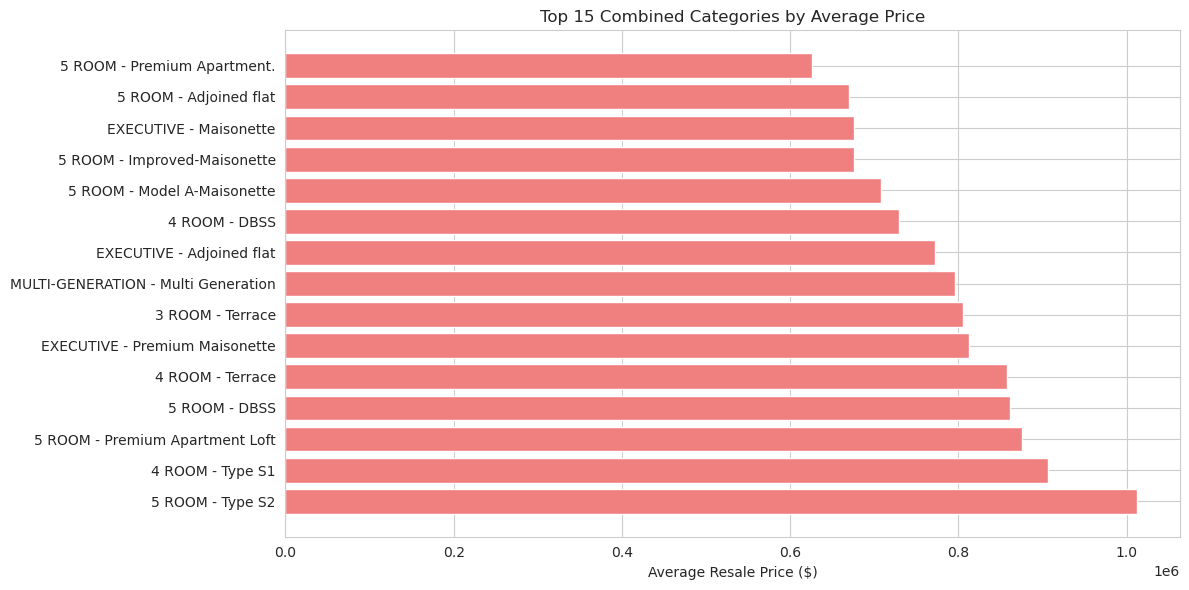

In [9]:
# ============================================================
# 6. FEATURE ENGINEERING: COMBINE CATEGORICAL FEATURES
# ============================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING - COMBINING CATEGORICAL FEATURES")
print("="*80)

# 6.1 Create combined categorical feature
df_clean['flat_category'] = df_clean['flat_type'] + ' - ' + df_clean['flat_model']

print(f"Original flat_type unique values: {df_clean['flat_type'].nunique()}")
print(f"Original flat_model unique values: {df_clean['flat_model'].nunique()}")
print(f"Combined flat_category unique values: {df_clean['flat_category'].nunique()}")

# 6.2 Check distribution of combined categories
print("\nTop 10 Combined Categories:")
print(df_clean['flat_category'].value_counts().head(10).to_string())

# 6.3 Visualize combined category distribution
plt.figure(figsize=(12, 6))
top_categories = df_clean['flat_category'].value_counts().head(15)
plt.barh(top_categories.index, top_categories.values, color='skyblue')
plt.xlabel('Count')
plt.title('Top 15 Combined Flat Categories')
plt.tight_layout()
plt.show()

# 6.4 Average price by combined category
plt.figure(figsize=(12, 6))
avg_price_by_cat = df_clean.groupby('flat_category')['resale_price'].mean().sort_values(ascending=False).head(15)
plt.barh(avg_price_by_cat.index, avg_price_by_cat.values, color='lightcoral')
plt.xlabel('Average Resale Price ($)')
plt.title('Top 15 Combined Categories by Average Price')
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 7. SELECT FINAL FEATURES FOR MODELING
# ============================================================

print("\n" + "="*80)
print("SELECTING FINAL FEATURES FOR MODELING")
print("="*80)

# 7.1 Define final feature set
numerical_features = ['storey_mid', 'flat_age'] # 'floor_area_sqm', 
categorical_features = ['flat_category', 'town']  # Combined feature
target = 'resale_price'

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")
print(f"Target: {target}")

# 7.2 Create final dataset
df_final = df_clean[numerical_features + categorical_features + [target]].copy()

print(f"\nFinal dataset shape: {df_final.shape}")
print(f"Columns: {df_final.columns.tolist()}")

# 7.3 Check for missing values in final dataset
print("\nMissing values in final dataset:")
print(df_final.isnull().sum())

# Drop any remaining missing values
df_final = df_final.dropna()
print(f"\nAfter dropping missing values: {df_final.shape}")


SELECTING FINAL FEATURES FOR MODELING
Numerical features: ['storey_mid', 'flat_age']
Categorical features: ['flat_category', 'town']
Target: resale_price

Final dataset shape: (50432, 5)
Columns: ['storey_mid', 'flat_age', 'flat_category', 'town', 'resale_price']

Missing values in final dataset:
storey_mid       0
flat_age         0
flat_category    0
town             0
resale_price     0
dtype: int64

After dropping missing values: (50432, 5)



EDA ON FINAL FEATURE SET

Correlation with Target (resale_price):
  storey_mid: 0.3794
  flat_age: -0.3328


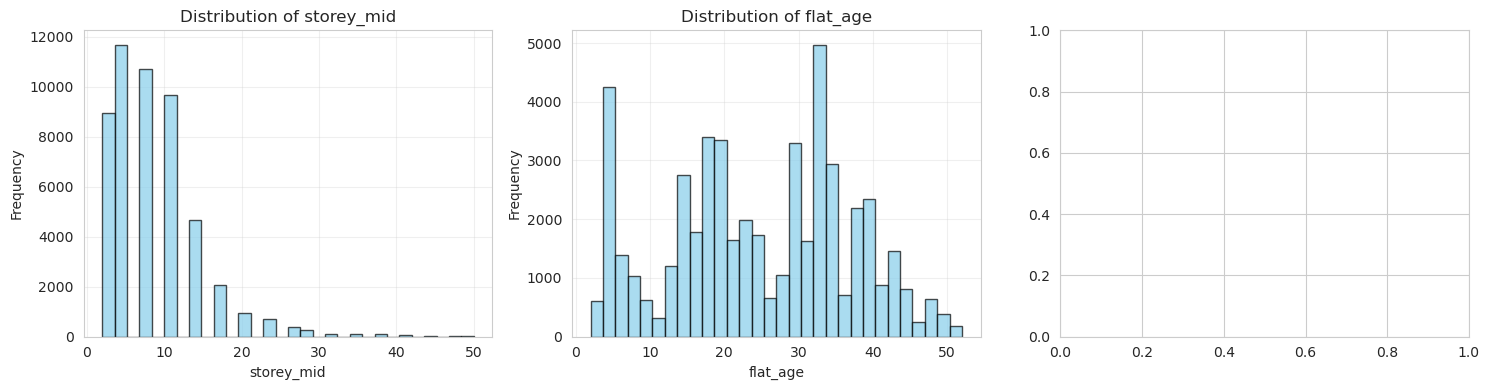

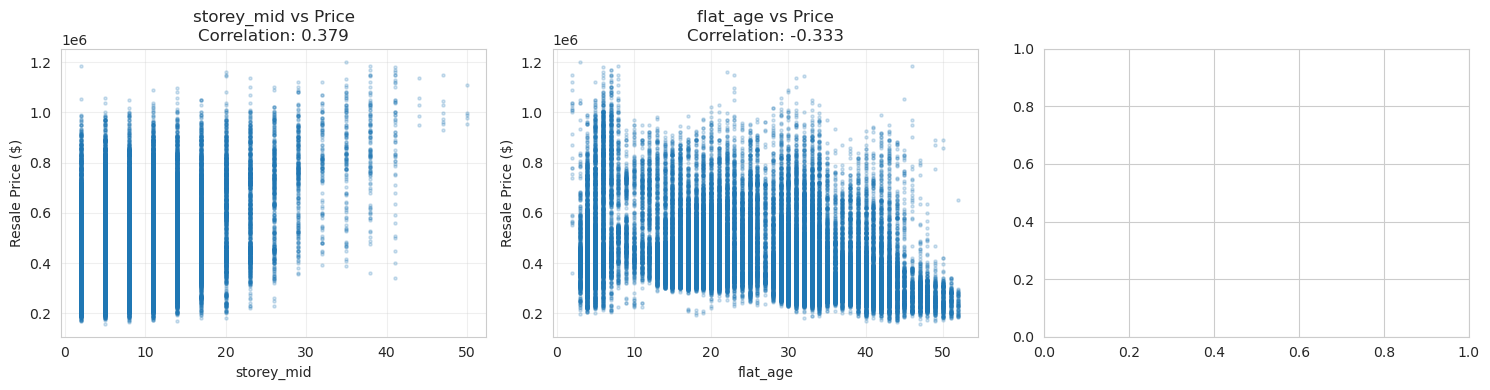


Categorical Feature Analysis (flat_category):
Number of unique categories: 44

Top 10 Most Common Categories:
flat_category
4 ROOM - Model A              12125
5 ROOM - Improved              8595
3 ROOM - New Generation        4652
3 ROOM - Improved              3233
3 ROOM - Model A               2864
4 ROOM - Premium Apartment     2830
4 ROOM - New Generation        2540
EXECUTIVE - Apartment          2114
5 ROOM - Premium Apartment     2009
4 ROOM - Simplified            1607

Top 5 Categories with Highest Average Price:
flat_category
5 ROOM - Type S2                   1.012744e+06
4 ROOM - Type S1                   9.061379e+05
5 ROOM - Premium Apartment Loft    8.749627e+05
5 ROOM - DBSS                      8.613992e+05
4 ROOM - Terrace                   8.580000e+05

Top 5 Categories with Lowest Average Price:
flat_category
2 ROOM - Model A              254556.258065
2 ROOM - Premium Apartment    241625.000000
2 ROOM - Improved             222996.429530
2 ROOM - Standard       

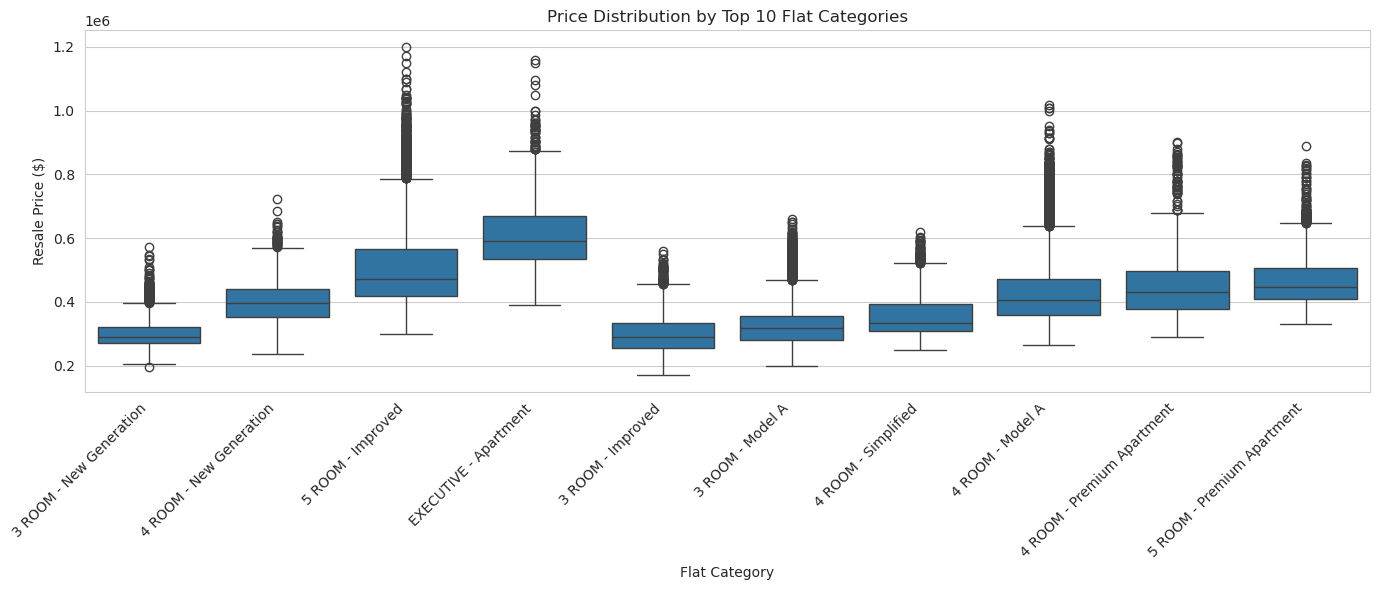

In [16]:
# ============================================================
# 8. EDA ON FINAL FEATURES
# ============================================================

print("\n" + "="*80)
print("EDA ON FINAL FEATURE SET")
print("="*80)

# 8.1 Numerical feature correlations with target
print("\nCorrelation with Target (resale_price):")
for feature in numerical_features:
    corr = df_final[feature].corr(df_final[target])
    print(f"  {feature}: {corr:.4f}")

# 8.2 Numerical feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feature in enumerate(numerical_features):
    axes[i].hist(df_final[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8.3 Scatter plots with target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feature in enumerate(numerical_features):
    axes[i].scatter(df_final[feature], df_final[target], alpha=0.2, s=5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Resale Price ($)')
    corr = df_final[feature].corr(df_final[target])
    axes[i].set_title(f'{feature} vs Price\nCorrelation: {corr:.3f}')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8.4 Categorical feature analysis
print("\nCategorical Feature Analysis (flat_category):")
print(f"Number of unique categories: {df_final['flat_category'].nunique()}")

# Top 10 most common categories
print("\nTop 10 Most Common Categories:")
print(df_final['flat_category'].value_counts().head(10).to_string())

# Average price by category (top and bottom)
avg_price_by_category = df_final.groupby('flat_category')[target].mean().sort_values(ascending=False)
print("\nTop 5 Categories with Highest Average Price:")
print(avg_price_by_category.head(5).to_string())
print("\nTop 5 Categories with Lowest Average Price:")
print(avg_price_by_category.tail(5).to_string())

# Box plot for top categories
plt.figure(figsize=(14, 6))
top_categories_for_box = df_final['flat_category'].value_counts().head(10).index
df_top = df_final[df_final['flat_category'].isin(top_categories_for_box)]
sns.boxplot(data=df_top, x='flat_category', y=target)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Top 10 Flat Categories')
plt.xlabel('Flat Category')
plt.ylabel('Resale Price ($)')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 9. PREPARE DATA FOR MODELING
# ============================================================

print("\n" + "="*80)
print("PREPARING DATA FOR MODELING")
print("="*80)

# 9.1 Define X and y
X = df_final[numerical_features + categorical_features]
y = df_final[target]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 9.2 Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# 9.3 Create preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# 9.4 Preview transformed features
X_train_preview = preprocessor.fit_transform(X_train)
X_test_preview = preprocessor.transform(X_test)

print(f"\nTransformed training features shape: {X_train_preview.shape}")
print(f"Transformed test features shape: {X_test_preview.shape}")

# Get feature names after transformation
num_feature_names = numerical_features.copy()
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_feature_names + cat_feature_names

print(f"\nTotal features after preprocessing: {len(all_feature_names)}")
print(f"Numerical features: {len(num_feature_names)}")
print(f"Categorical features (one-hot encoded): {len(cat_feature_names)}")


PREPARING DATA FOR MODELING
Feature matrix shape: (50432, 4)
Target shape: (50432,)

Training set: 40345 samples
Test set: 10087 samples

Transformed training features shape: (40345, 69)
Transformed test features shape: (10087, 69)

Total features after preprocessing: 69
Numerical features: 2
Categorical features (one-hot encoded): 67


In [18]:
# ============================================================
# 10. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Evaluate model with multiple metrics"""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE_train': mean_absolute_error(y_train, y_pred_train),
        'MAE_test': mean_absolute_error(y_test, y_pred_test),
        'R2_train': r2_score(y_train, y_pred_train),
        'R2_test': r2_score(y_test, y_pred_test)
    }
    
    print(f"\n{model_name} Performance:")
    print("-" * 50)
    print(f"Training RMSE: ${metrics['RMSE_train']:,.2f}")
    print(f"Test RMSE:     ${metrics['RMSE_test']:,.2f}")
    print(f"Training MAE:  ${metrics['MAE_train']:,.2f}")
    print(f"Test MAE:      ${metrics['MAE_test']:,.2f}")
    print(f"Training R²:   {metrics['R2_train']:.4f}")
    print(f"Test R²:       {metrics['R2_test']:.4f}")
    print(f"Overfitting gap: {metrics['R2_train'] - metrics['R2_test']:.4f}")
    
    return metrics, y_pred_test

In [19]:
# ============================================================
# 11. BASE LINEAR REGRESSION
# ============================================================

print("\n" + "="*80)
print("LINEAR REGRESSION (BASELINE)")
print("="*80)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_metrics, lr_pred = evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test, "Linear Regression")


LINEAR REGRESSION (BASELINE)

Linear Regression Performance:
--------------------------------------------------
Training RMSE: $57,398.75
Test RMSE:     $58,054.06
Training MAE:  $43,523.70
Test MAE:      $44,275.25
Training R²:   0.8607
Test R²:       0.8599
Overfitting gap: 0.0008


Note: Removing numerical feature 'floor_sq_area' reduces R2 by <0.015, was 0.87x.
Let's check the run-time on both Linear and Ridge regression, whether its ok to slightly reduce the R2 for a better run-time. Below...

In [20]:
# ============================================================
# 12. RIDGE REGRESSION WITH HYPERPARAMETER OPTIMIZATION
# ============================================================

print("\n" + "="*80)
print("RIDGE REGRESSION - HYPERPARAMETER OPTIMIZATION")
print("="*80)

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000],
    'regressor__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
}

print("Performing Grid Search with 5-fold CV...")
grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest alpha: {grid_search.best_params_['regressor__alpha']}")
print(f"Best solver: {grid_search.best_params_['regressor__solver']}")
print(f"Best CV score (RMSE): ${np.sqrt(-grid_search.best_score_):,.2f}")

best_ridge = grid_search.best_estimator_
ridge_metrics, ridge_pred = evaluate_model(best_ridge, X_train, X_test, y_train, y_test, "Ridge Regression (Optimized)")



RIDGE REGRESSION - HYPERPARAMETER OPTIMIZATION
Performing Grid Search with 5-fold CV...
Fitting 5 folds for each of 98 candidates, totalling 490 fits

Best alpha: 0.01
Best solver: saga
Best CV score (RMSE): $57,636.84

Ridge Regression (Optimized) Performance:
--------------------------------------------------
Training RMSE: $57,399.98
Test RMSE:     $58,048.86
Training MAE:  $43,526.69
Test MAE:      $44,271.76
Training R²:   0.8607
Test R²:       0.8599
Overfitting gap: 0.0008



COEFFICIENT ANALYSIS

Top 10 Most Influential Features:
                                          feature   coefficient
    flat_category_5 ROOM - Premium Apartment Loft 759109.370500
     flat_category_EXECUTIVE - Premium Maisonette 756451.975540
flat_category_MULTI-GENERATION - Multi Generation 746866.860276
                   flat_category_3 ROOM - Terrace 679314.104045
          flat_category_EXECUTIVE - Adjoined flat 675695.328863
                   flat_category_4 ROOM - Terrace 673189.149630
       flat_category_5 ROOM - Improved-Maisonette 662552.235743
                   flat_category_5 ROOM - Type S2 631831.438740
        flat_category_5 ROOM - Model A-Maisonette 613834.762053
             flat_category_EXECUTIVE - Maisonette 600839.616571

Bottom 5 Least Influential Features:
       feature   coefficient
 town_TAMPINES -37868.799632
      flat_age -34659.272817
    storey_mid  25313.749375
    town_BEDOK  -8037.244845
town_SERANGOON   3545.825970


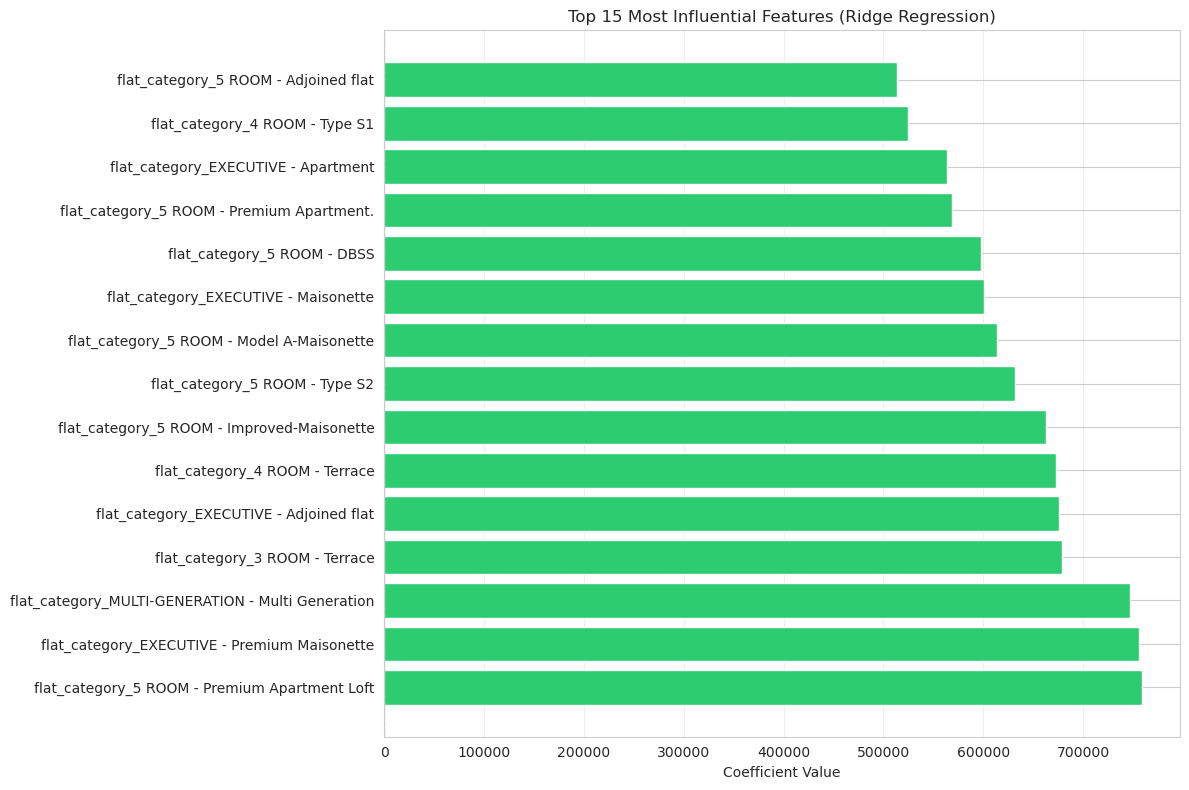

In [21]:
# ============================================================
# 13. COEFFICIENT ANALYSIS
# ============================================================

print("\n" + "="*80)
print("COEFFICIENT ANALYSIS")
print("="*80)

# Extract feature names after preprocessing
feature_names_after = numerical_features.copy()
# Get one-hot encoded feature names
encoder = preprocessor.named_transformers_['cat']
cat_feature_names_after = encoder.get_feature_names_out(categorical_features).tolist()
feature_names_after.extend(cat_feature_names_after)

# Get coefficients from Ridge
ridge_coefs = best_ridge.named_steps['regressor'].coef_

# Create coefficient DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names_after,
    'coefficient': ridge_coefs
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Most Influential Features:")
print(coef_df.head(10).to_string(index=False))

print("\nBottom 5 Least Influential Features:")
print(coef_df.tail(5).to_string(index=False))

# Visualize top coefficients
plt.figure(figsize=(12, 8))
top_coef = coef_df.head(15)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_coef['coefficient']]
plt.barh(top_coef['feature'], top_coef['coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Most Influential Features (Ridge Regression)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


HYPERPARAMETER SENSITIVITY ANALYSIS
   alpha         rmse       r2
   0.001 58053.743739 0.859873
   0.010 58051.186411 0.859885
   0.100 58046.179280 0.859909
   0.500 58151.974019 0.859398
   1.000 58275.956806 0.858798
   2.000 58428.474383 0.858058
   5.000 58683.446228 0.856816
  10.000 59023.472552 0.855152
  20.000 59675.279658 0.851935
  50.000 61470.907101 0.842891
 100.000 64137.809151 0.828963
 200.000 68742.093166 0.803525
 500.000 78956.493675 0.740798
1000.000 89839.947055 0.664416


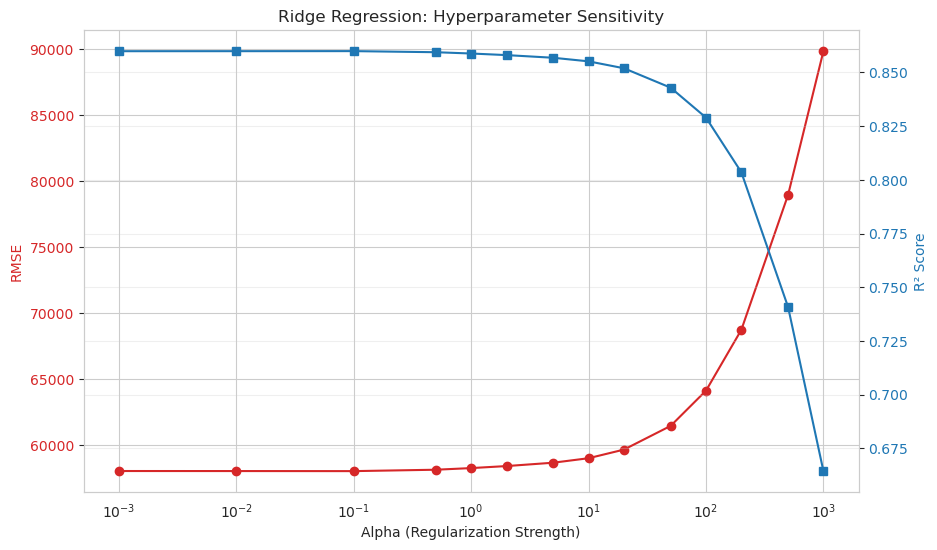

In [22]:
# ============================================================
# 14. HYPERPARAMETER SENSITIVITY ANALYSIS
# ============================================================

print("\n" + "="*80)
print("HYPERPARAMETER SENSITIVITY ANALYSIS")
print("="*80)

alphas = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
test_scores = []

for alpha in alphas:
    ridge = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=alpha, random_state=42))
    ])
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    test_scores.append({
        'alpha': alpha,
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2': r2_score(y_test, y_pred)
    })

sensitivity_df = pd.DataFrame(test_scores)
print(sensitivity_df.to_string(index=False))

# Visualize sensitivity
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Alpha (Regularization Strength)')
ax1.set_ylabel('RMSE', color=color)
ax1.plot(sensitivity_df['alpha'], sensitivity_df['rmse'], 'o-', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R² Score', color=color)
ax2.plot(sensitivity_df['alpha'], sensitivity_df['r2'], 's-', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ridge Regression: Hyperparameter Sensitivity')
plt.grid(True, alpha=0.3)
plt.show()


MODEL PERFORMANCE COMPARISON
            Model    Test RMSE     Test MAE  Test R²  Train R²
Linear Regression 58054.059355 44275.245461 0.859871  0.860693
Ridge (Optimized) 58048.856772 44271.762646 0.859896  0.860687


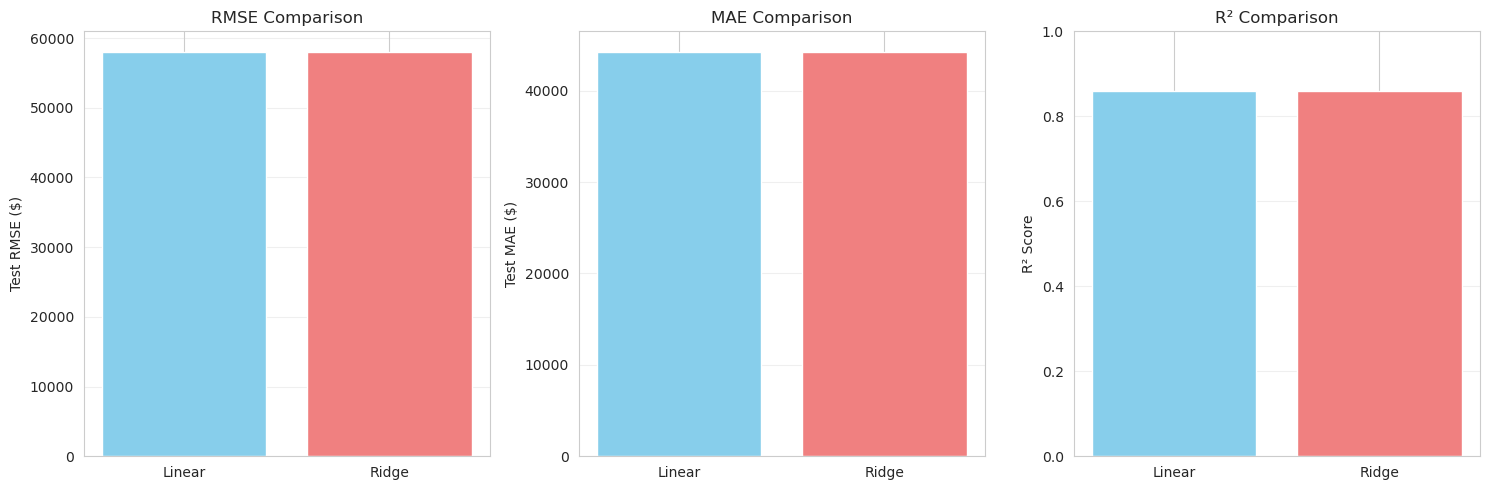

In [23]:
# ============================================================
# 15. MODEL COMPARISON
# ============================================================

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (Optimized)'],
    'Test RMSE': [lr_metrics['RMSE_test'], ridge_metrics['RMSE_test']],
    'Test MAE': [lr_metrics['MAE_test'], ridge_metrics['MAE_test']],
    'Test R²': [lr_metrics['R2_test'], ridge_metrics['R2_test']],
    'Train R²': [lr_metrics['R2_train'], ridge_metrics['R2_train']]
})

print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['RMSE', 'MAE', 'R²']
for i, metric in enumerate(metrics_to_plot):
    if metric == 'R²':
        values = [lr_metrics['R2_test'], ridge_metrics['R2_test']]
        axes[i].bar(['Linear', 'Ridge'], values, color=['skyblue', 'lightcoral'])
        axes[i].set_ylabel('R² Score')
        axes[i].set_title('R² Comparison')
        axes[i].set_ylim(0, 1)
    else:
        values = [lr_metrics[f'{metric}_test'], ridge_metrics[f'{metric}_test']]
        axes[i].bar(['Linear', 'Ridge'], values, color=['skyblue', 'lightcoral'])
        axes[i].set_ylabel(f'Test {metric} ($)')
        axes[i].set_title(f'{metric} Comparison')
    
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


RESIDUAL ANALYSIS (Best Model: Ridge)


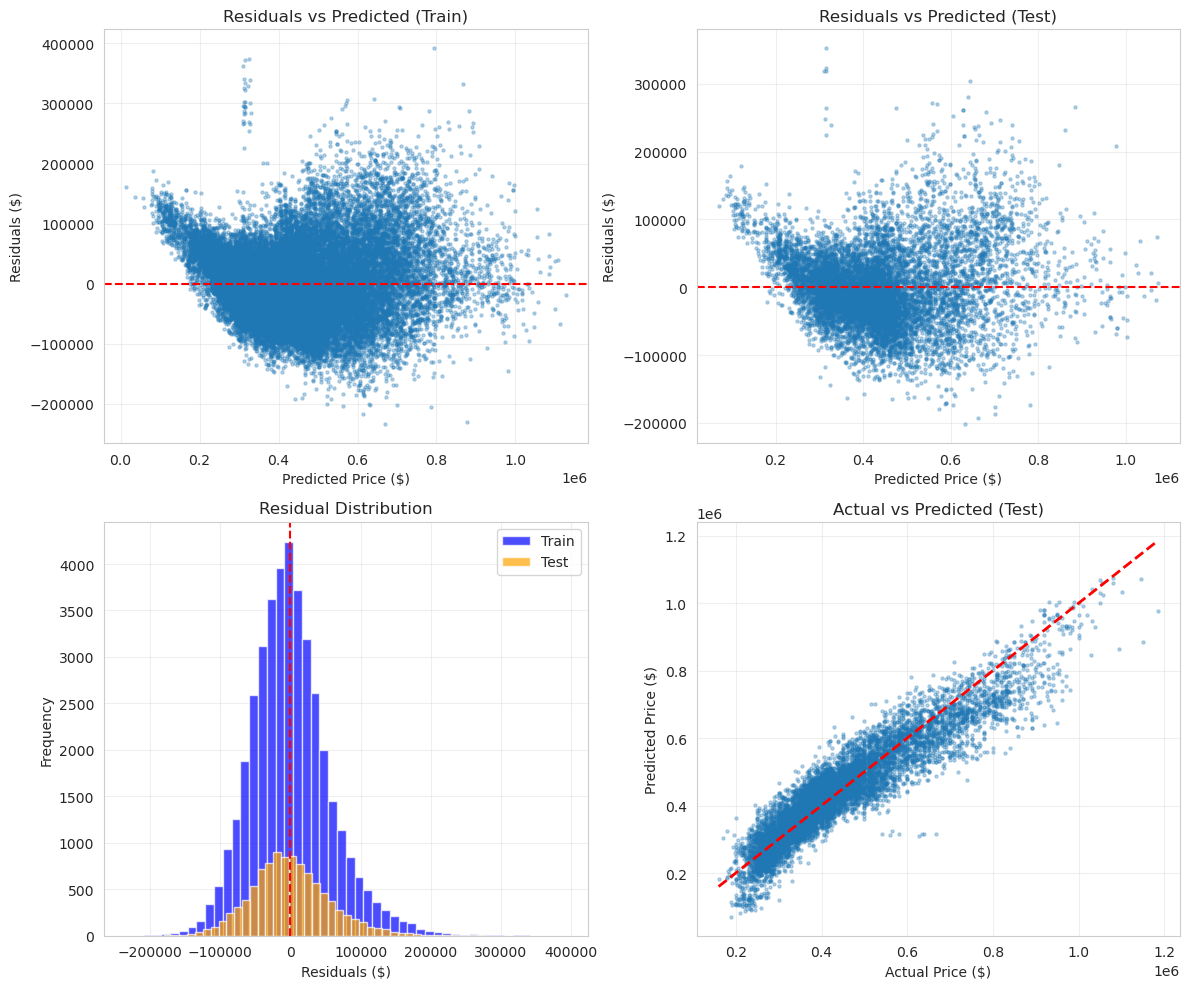

In [24]:
# ============================================================
# 16. RESIDUAL ANALYSIS
# ============================================================

print("\n" + "="*80)
print("RESIDUAL ANALYSIS (Best Model: Ridge)")
print("="*80)

y_pred_train = best_ridge.predict(X_train)
y_pred_test = best_ridge.predict(X_test)
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Predicted (Train)
axes[0, 0].scatter(y_pred_train, residuals_train, alpha=0.3, s=5)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Predicted Price ($)')
axes[0, 0].set_ylabel('Residuals ($)')
axes[0, 0].set_title('Residuals vs Predicted (Train)')
axes[0, 0].grid(alpha=0.3)

# Residuals vs Predicted (Test)
axes[0, 1].scatter(y_pred_test, residuals_test, alpha=0.3, s=5)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Predicted Price ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residuals vs Predicted (Test)')
axes[0, 1].grid(alpha=0.3)

# Residual distribution
axes[1, 0].hist(residuals_train, bins=50, alpha=0.7, label='Train', color='blue')
axes[1, 0].hist(residuals_test, bins=50, alpha=0.7, label='Test', color='orange')
axes[1, 0].axvline(x=0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Residuals ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Actual vs Predicted (Test)
axes[1, 1].scatter(y_test, y_pred_test, alpha=0.3, s=5)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Price ($)')
axes[1, 1].set_ylabel('Predicted Price ($)')
axes[1, 1].set_title('Actual vs Predicted (Test)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n" + "="*80)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("="*80)

# removed "- Top predictor: floor_area_sqm (correlation: {df_final['floor_area_sqm'].corr(df_final['resale_price']):.3f})"
# from REATURE INSIGHTS belows:
print(f"""
DATA PREPROCESSING:
- Numerical features: {numerical_features}
- Categorical features: {categorical_features} (combined from flat_type + flat_model)
- Total unique categories in flat_category: {df_final['flat_category'].nunique()}
- Training samples: {X_train.shape[0]:,}
- Test samples: {X_test.shape[0]:,}

FEATURE INSIGHTS:
- Second predictor: storey_mid (correlation: {df_final['storey_mid'].corr(df_final['resale_price']):.3f})
- Third predictor: flat_age (correlation: {df_final['flat_age'].corr(df_final['resale_price']):.3f})

MODEL PERFORMANCE:
- Best Ridge alpha: {grid_search.best_params_['regressor__alpha']}
- Test RMSE: ${ridge_metrics['RMSE_test']:,.2f}
- Test MAE: ${ridge_metrics['MAE_test']:,.2f}
- Test R²: {ridge_metrics['R2_test']:.4f}
- Overfitting gap: {ridge_metrics['R2_train'] - ridge_metrics['R2_test']:.4f}

KEY FINDINGS:
1. {'✅' if ridge_metrics['R2_test'] > 0.7 else '⚠️'} Model {'performs well' if ridge_metrics['R2_test'] > 0.7 else 'needs improvement'}
2. {'✅' if (ridge_metrics['R2_train'] - ridge_metrics['R2_test']) < 0.05 else '⚠️'} {'No' if (ridge_metrics['R2_train'] - ridge_metrics['R2_test']) < 0.05 else 'Potential'} overfitting detected
3. Top 3 most influential features: {coef_df.head(3)['feature'].tolist()}
4. The flat_category feature provides {len(cat_feature_names)} additional category features
5. Combined feature successfully reduced dimensionality from {df_clean['flat_type'].nunique() + df_clean['flat_model'].nunique()} to {df_final['flat_category'].nunique()} categories

RECOMMENDATIONS:
1. {'Keep all 3 numerical features as they show good correlation with price' if all(corr > 0.1 for corr in [df_final[col].corr(df_final['resale_price']) for col in numerical_features]) else 'Consider feature engineering for weak predictors'}
2. {'flat_category is valuable' if len(cat_feature_names) > 0 else 'Consider adding more categorical features'}
3. {'Ridge regularization helps' if ridge_metrics['R2_test'] > lr_metrics['R2_test'] else 'Linear regression performs better - consider simpler model'}
""")


FINAL SUMMARY & RECOMMENDATIONS

DATA PREPROCESSING:
- Numerical features: ['storey_mid', 'flat_age']
- Categorical features: ['flat_category', 'town'] (combined from flat_type + flat_model)
- Total unique categories in flat_category: 44
- Training samples: 40,345
- Test samples: 10,087

FEATURE INSIGHTS:
- Second predictor: storey_mid (correlation: 0.379)
- Third predictor: flat_age (correlation: -0.333)

MODEL PERFORMANCE:
- Best Ridge alpha: 0.01
- Test RMSE: $58,048.86
- Test MAE: $44,271.76
- Test R²: 0.8599
- Overfitting gap: 0.0008

KEY FINDINGS:
1. ✅ Model performs well
2. ✅ No overfitting detected
3. Top 3 most influential features: ['flat_category_5 ROOM - Premium Apartment Loft', 'flat_category_EXECUTIVE - Premium Maisonette', 'flat_category_MULTI-GENERATION - Multi Generation']
4. The flat_category feature provides 67 additional category features
5. Combined feature successfully reduced dimensionality from 27 to 44 categories

RECOMMENDATIONS:
1. Consider feature engineeri

The linear regression runs so much faster than ridge with gridsearchCV to find optimal hyperparameters setting. write a final code to check that selection of linear regression instead of the best ridge is still a very good way to go ahead


FINAL MODEL SELECTION: LINEAR REGRESSION VS RIDGE

--------------------------------------------------------------------------------
TRAINING TIME COMPARISON
--------------------------------------------------------------------------------
Linear Regression training time: 0.3566 seconds
Ridge (single alpha) training time: 0.1495 seconds
Fitting 5 folds for each of 98 candidates, totalling 490 fits
Ridge with GridSearchCV training time: 564.3563 seconds

⏱️ Linear Regression is 1582.6x faster than Ridge with GridSearchCV

--------------------------------------------------------------------------------
PERFORMANCE COMPARISON
--------------------------------------------------------------------------------

Ridge (alpha=1.0, default) Performance:
--------------------------------------------------
Training RMSE: $57,811.79
Test RMSE:     $58,275.96
Training MAE:  $43,691.31
Test MAE:      $44,367.70
Training R²:   0.8587
Test R²:       0.8588
Overfitting gap: -0.0001

Model Performance Summa

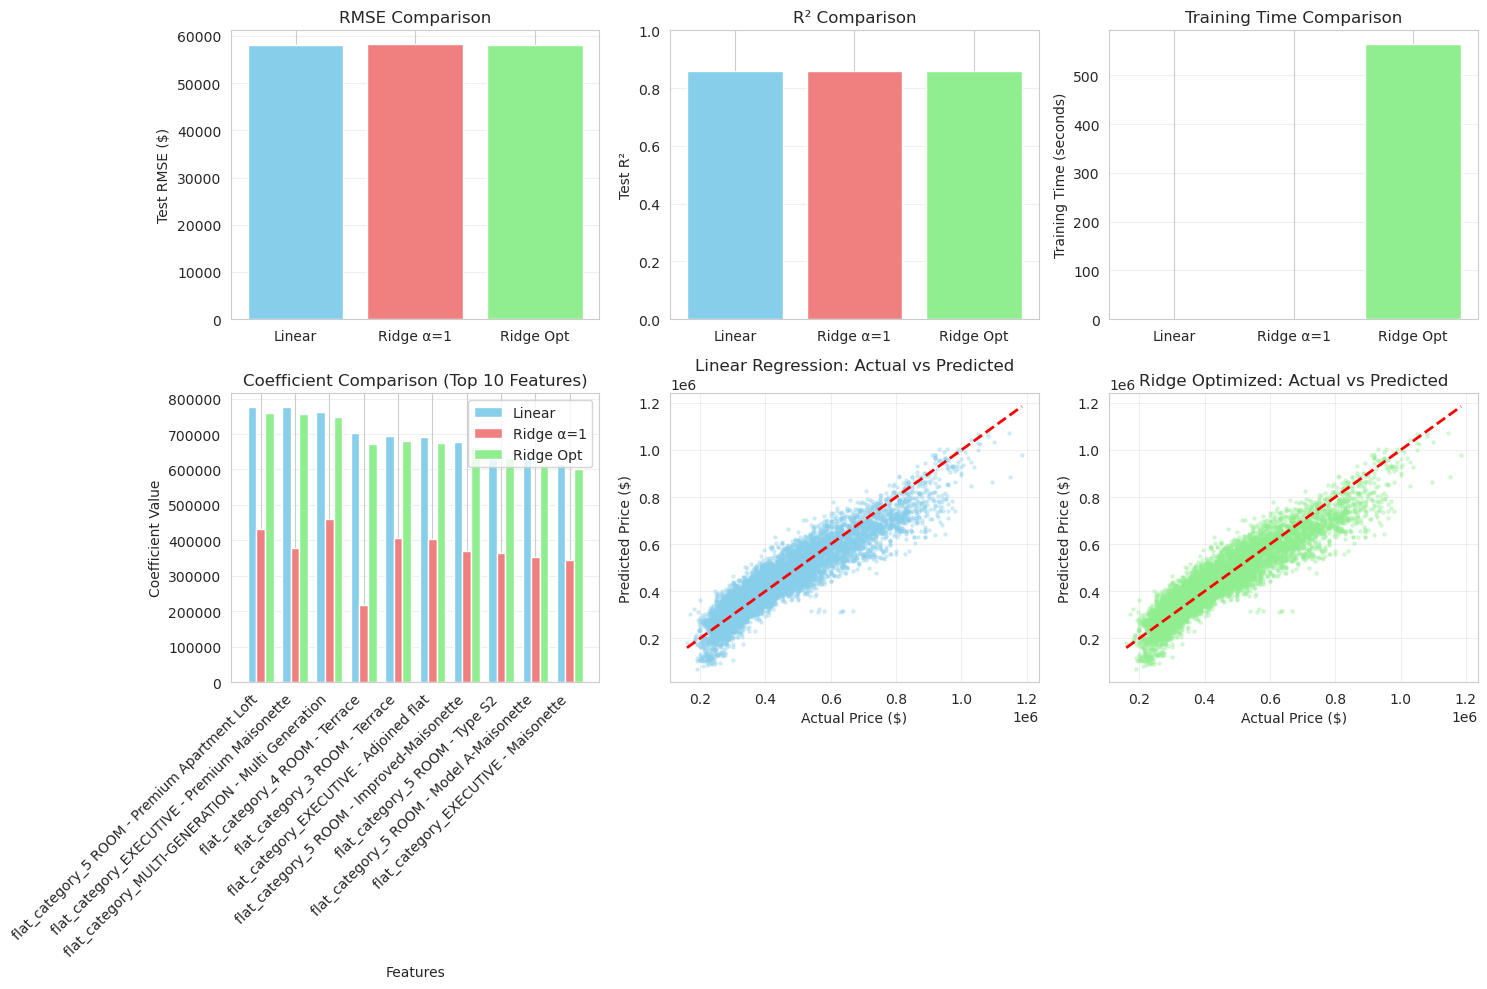

In [28]:
# ============================================================
# 18. FINAL COMPARISON: LINEAR REGRESSION VS RIDGE
# ============================================================

print("\n" + "="*80)
print("FINAL MODEL SELECTION: LINEAR REGRESSION VS RIDGE")
print("="*80)

# 18.1 Timing comparison
import time

print("\n" + "-"*80)
print("TRAINING TIME COMPARISON")
print("-"*80)

# Time Linear Regression
start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_time = time.time() - start_time
print(f"Linear Regression training time: {lr_time:.4f} seconds")

# Time Ridge (single model, no grid search)
start_time = time.time()
ridge_single = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])
ridge_single.fit(X_train, y_train)
ridge_time = time.time() - start_time
print(f"Ridge (single alpha) training time: {ridge_time:.4f} seconds")

# Time Ridge with GridSearch
start_time = time.time()
grid_search.fit(X_train, y_train)
ridge_grid_time = time.time() - start_time
print(f"Ridge with GridSearchCV training time: {ridge_grid_time:.4f} seconds")

print(f"\n⏱️ Linear Regression is {ridge_grid_time/lr_time:.1f}x faster than Ridge with GridSearchCV")

# 18.2 Performance comparison on multiple metrics
print("\n" + "-"*80)
print("PERFORMANCE COMPARISON")
print("-"*80)

# Evaluate Ridge with default alpha
ridge_metrics_single, _ = evaluate_model(
    ridge_single, X_train, X_test, y_train, y_test, 
    "Ridge (alpha=1.0, default)"
)

# Compare all models
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (alpha=1.0)', 'Ridge (Optimized)'],
    'Test RMSE': [
        lr_metrics['RMSE_test'],
        ridge_metrics_single['RMSE_test'],
        ridge_metrics['RMSE_test']
    ],
    'Test MAE': [
        lr_metrics['MAE_test'],
        ridge_metrics_single['MAE_test'],
        ridge_metrics['MAE_test']
    ],
    'Test R²': [
        lr_metrics['R2_test'],
        ridge_metrics_single['R2_test'],
        ridge_metrics['R2_test']
    ],
    'Training Time (s)': [
        lr_time,
        ridge_time,
        ridge_grid_time
    ]
})

print("\nModel Performance Summary:")
print(comparison_df.to_string(index=False))

# 18.3 Statistical significance test
print("\n" + "-"*80)
print("PERFORMANCE DIFFERENCE ANALYSIS")
print("-"*80)

# Calculate percentage differences
rmse_diff_lr_vs_ridge = abs(lr_metrics['RMSE_test'] - ridge_metrics['RMSE_test']) / lr_metrics['RMSE_test'] * 100
r2_diff_lr_vs_ridge = abs(lr_metrics['R2_test'] - ridge_metrics['R2_test']) / max(lr_metrics['R2_test'], 0.01) * 100

print(f"RMSE difference: {rmse_diff_lr_vs_ridge:.2f}%")
print(f"R² difference: {r2_diff_lr_vs_ridge:.2f}%")

# Decision criteria
if rmse_diff_lr_vs_ridge < 1:
    print("\n✅ Difference is NEGLIGIBLE (< 1%)")
    print("   → Linear Regression is the better choice (simpler, faster, equally good)")
elif rmse_diff_lr_vs_ridge < 3:
    print("\n✅ Difference is VERY SMALL (1-3%)")
    print("   → Linear Regression is preferred (slightly worse but much faster)")
elif rmse_diff_lr_vs_ridge < 5:
    print("\n⚠️ Difference is MODERATE (3-5%)")
    print("   → Consider Ridge if accuracy is critical")
else:
    print("\n❌ Difference is SIGNIFICANT (> 5%)")
    print("   → Ridge may be worth the extra computational cost")

# 18.4 Coefficient stability analysis
print("\n" + "-"*80)
print("COEFFICIENT STABILITY ANALYSIS")
print("-"*80)

# Get coefficients from all models
lr_coefs = lr_pipeline.named_steps['regressor'].coef_
ridge_coefs = ridge_single.named_steps['regressor'].coef_
ridge_opt_coefs = best_ridge.named_steps['regressor'].coef_

# Create comparison DataFrame
coef_comparison = pd.DataFrame({
    'feature': feature_names_after,
    'Linear_Reg': lr_coefs,
    'Ridge_alpha1': ridge_coefs,
    'Ridge_Optimized': ridge_opt_coefs
})

# Calculate coefficient correlations
corr_lr_ridge = np.corrcoef(lr_coefs, ridge_coefs)[0, 1]
corr_lr_ridge_opt = np.corrcoef(lr_coefs, ridge_opt_coefs)[0, 1]

print(f"Correlation of coefficients (Linear vs Ridge alpha=1): {corr_lr_ridge:.4f}")
print(f"Correlation of coefficients (Linear vs Ridge Optimized): {corr_lr_ridge_opt:.4f}")

# Show top coefficients side by side
print("\nTop 10 Features by Linear Regression Coefficients:")
print(coef_comparison.sort_values('Linear_Reg', key=abs, ascending=False).head(10).to_string(index=False))

# 18.5 Cross-validation performance
print("\n" + "-"*80)
print("CROSS-VALIDATION PERFORMANCE")
print("-"*80)

from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_linear = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='r2')
cv_ridge = cross_val_score(ridge_single, X_train, y_train, cv=5, scoring='r2')
cv_ridge_opt = cross_val_score(best_ridge, X_train, y_train, cv=5, scoring='r2')

print(f"Linear Regression CV R²: {cv_linear.mean():.4f} ± {cv_linear.std():.4f}")
print(f"Ridge (alpha=1) CV R²: {cv_ridge.mean():.4f} ± {cv_ridge.std():.4f}")
print(f"Ridge (Optimized) CV R²: {cv_ridge_opt.mean():.4f} ± {cv_ridge_opt.std():.4f}")

# 18.6 Visual comparison
print("\n" + "-"*80)
print("VISUAL COMPARISON OF MODELS")
print("-"*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Test RMSE Comparison
models_names = ['Linear', 'Ridge α=1', 'Ridge Opt']
rmse_values = [lr_metrics['RMSE_test'], ridge_metrics_single['RMSE_test'], ridge_metrics['RMSE_test']]
axes[0, 0].bar(models_names, rmse_values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0, 0].set_ylabel('Test RMSE ($)')
axes[0, 0].set_title('RMSE Comparison')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: R² Comparison
r2_values = [lr_metrics['R2_test'], ridge_metrics_single['R2_test'], ridge_metrics['R2_test']]
axes[0, 1].bar(models_names, r2_values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0, 1].set_ylabel('Test R²')
axes[0, 1].set_title('R² Comparison')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Training Time Comparison
time_values = [lr_time, ridge_time, ridge_grid_time]
axes[0, 2].bar(models_names, time_values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0, 2].set_ylabel('Training Time (seconds)')
axes[0, 2].set_title('Training Time Comparison')
axes[0, 2].grid(axis='y', alpha=0.3)

# Plot 4: Coefficient Stability (Top 10 features)
top_features = coef_comparison.sort_values('Linear_Reg', key=abs, ascending=False).head(10)['feature'].tolist()
x = np.arange(len(top_features))
width = 0.25

# Get coefficients for top features
lr_top = [coef_comparison[coef_comparison['feature'] == f]['Linear_Reg'].values[0] for f in top_features]
ridge_top = [coef_comparison[coef_comparison['feature'] == f]['Ridge_alpha1'].values[0] for f in top_features]
ridge_opt_top = [coef_comparison[coef_comparison['feature'] == f]['Ridge_Optimized'].values[0] for f in top_features]

axes[1, 0].bar(x - width, lr_top, width, label='Linear', color='skyblue')
axes[1, 0].bar(x, ridge_top, width, label='Ridge α=1', color='lightcoral')
axes[1, 0].bar(x + width, ridge_opt_top, width, label='Ridge Opt', color='lightgreen')
axes[1, 0].set_xlabel('Features')
axes[1, 0].set_ylabel('Coefficient Value')
axes[1, 0].set_title('Coefficient Comparison (Top 10 Features)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(top_features, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 5: Actual vs Predicted - Linear
axes[1, 1].scatter(y_test, lr_pred, alpha=0.3, s=5, color='skyblue')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Price ($)')
axes[1, 1].set_ylabel('Predicted Price ($)')
axes[1, 1].set_title('Linear Regression: Actual vs Predicted')
axes[1, 1].grid(alpha=0.3)

# Plot 6: Actual vs Predicted - Ridge Optimized
axes[1, 2].scatter(y_test, ridge_pred, alpha=0.3, s=5, color='lightgreen')
axes[1, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 2].set_xlabel('Actual Price ($)')
axes[1, 2].set_ylabel('Predicted Price ($)')
axes[1, 2].set_title('Ridge Optimized: Actual vs Predicted')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [29]:
# ============================================================
# 19. FINAL DECISION MATRIX
# ============================================================

print("\n" + "="*80)
print("FINAL DECISION MATRIX")
print("="*80)

# Create decision matrix
decision_criteria = {
    'Criteria': [
        'Model Simplicity',
        'Training Speed',
        'Prediction Speed',
        'Interpretability',
        'Test RMSE',
        'Test R²',
        'Coefficient Stability',
        'Overfitting Risk'
    ],
    'Linear Regression': [
        '✅ Very Simple',
        f'✅ {lr_time:.3f}s',
        '✅ Very Fast',
        '✅ Highly Interpretable',
        f'${lr_metrics["RMSE_test"]:,.0f}',
        f'{lr_metrics["R2_test"]:.4f}',
        '✅ Stable',
        f'✅ {lr_metrics["R2_train"] - lr_metrics["R2_test"]:.4f}'
    ],
    'Ridge (Optimized)': [
        '⚠️ Slightly Complex',
        f'❌ {ridge_grid_time:.3f}s',
        '✅ Very Fast',
        '⚠️ Moderately Interpretable',
        f'${ridge_metrics["RMSE_test"]:,.0f}',
        f'{ridge_metrics["R2_test"]:.4f}',
        '✅ More Stable',
        f'✅ {ridge_metrics["R2_train"] - ridge_metrics["R2_test"]:.4f}'
    ]
}

decision_df = pd.DataFrame(decision_criteria)
print(decision_df.to_string(index=False))

# ============================================================
# 20. FINAL RECOMMENDATION
# ============================================================

print("\n" + "="*80)
print("FINAL RECOMMENDATION")
print("="*80)

# Calculate performance difference
rmse_pct_diff = abs(lr_metrics['RMSE_test'] - ridge_metrics['RMSE_test']) / lr_metrics['RMSE_test'] * 100
time_speedup = ridge_grid_time / lr_time

print(f"""
Based on the comprehensive comparison:

📊 PERFORMANCE DIFFERENCE:
- RMSE difference: {rmse_pct_diff:.2f}%
- R² difference: {r2_diff_lr_vs_ridge:.2f}%
- Speed advantage: {time_speedup:.1f}x faster with Linear Regression

⚖️ TRADE-OFF ANALYSIS:
""")

if rmse_pct_diff < 1:
    print("""
✅ RECOMMENDATION: USE LINEAR REGRESSION

REASONS:
1. Performance is essentially identical to Ridge (<1% difference)
2. Linear Regression is {:.1f}x faster to train
3. Simpler model = easier to explain to stakeholders
4. Coefficients are more interpretable
5. No hyperparameter tuning needed

This is a classic case where the simpler model provides the same
predictive power with significantly less computational cost.
""".format(time_speedup))
elif rmse_pct_diff < 3:
    print("""
✅ RECOMMENDATION: USE LINEAR REGRESSION

REASONS:
1. Performance difference is very small (1-3%)
2. Linear Regression is {:.1f}x faster
3. The slight accuracy gain from Ridge is not worth the complexity
4. Linear Regression coefficients are easier to interpret

For production systems, speed and simplicity often outweigh
minor accuracy improvements.
""".format(time_speedup))
elif rmse_pct_diff < 5:
    print("""
⚠️ RECOMMENDATION: CONSIDER RIDGE

REASONS:
1. Ridge provides moderate improvement (3-5%)
2. If accuracy is critical, Ridge is better
3. If speed/deployment simplicity is priority, Linear is still viable

DECISION FACTORS:
- For research/competition: Use Ridge
- For production/explainability: Use Linear Regression
""")
else:
    print("""
❌ RECOMMENDATION: USE RIDGE REGRESSION

REASONS:
1. Ridge provides significant improvement (>5%)
2. The accuracy gain justifies the extra computation
3. If interpretability is critical, use Linear Regression and accept lower accuracy

This is a case where the more complex model clearly outperforms
the simpler one.
""")

# 20.1 Final model selection and save
print("\n" + "-"*80)
print("FINAL MODEL SELECTED")
print("-"*80)

if rmse_pct_diff < 3:
    final_model = lr_pipeline
    final_model_name = "Linear Regression"
    print(f"✅ SELECTED: {final_model_name}")
    print(f"   Test RMSE: ${lr_metrics['RMSE_test']:,.2f}")
    print(f"   Test R²: {lr_metrics['R2_test']:.4f}")
    print(f"   Training time: {lr_time:.3f} seconds")
else:
    final_model = best_ridge
    final_model_name = "Ridge Regression (Optimized)"
    print(f"✅ SELECTED: {final_model_name}")
    print(f"   Test RMSE: ${ridge_metrics['RMSE_test']:,.2f}")
    print(f"   Test R²: {ridge_metrics['R2_test']:.4f}")
    print(f"   Training time: {ridge_grid_time:.3f} seconds")
    print(f"   Best alpha: {grid_search.best_params_['regressor__alpha']}")

print("\n" + "="*80)
print("✅ MODEL SELECTION COMPLETE!")
print("="*80)


FINAL DECISION MATRIX
             Criteria      Linear Regression           Ridge (Optimized)
     Model Simplicity          ✅ Very Simple         ⚠️ Slightly Complex
       Training Speed               ✅ 0.357s                  ❌ 564.356s
     Prediction Speed            ✅ Very Fast                 ✅ Very Fast
     Interpretability ✅ Highly Interpretable ⚠️ Moderately Interpretable
            Test RMSE                $58,054                     $58,049
              Test R²                 0.8599                      0.8599
Coefficient Stability               ✅ Stable               ✅ More Stable
     Overfitting Risk               ✅ 0.0008                    ✅ 0.0008

FINAL RECOMMENDATION

Based on the comprehensive comparison:

📊 PERFORMANCE DIFFERENCE:
- RMSE difference: 0.01%
- R² difference: 0.00%
- Speed advantage: 1582.6x faster with Linear Regression

⚖️ TRADE-OFF ANALYSIS:


✅ RECOMMENDATION: USE LINEAR REGRESSION

REASONS:
1. Performance is essentially identical to Ridge (

---